In [ ]:
pip install wordcloud

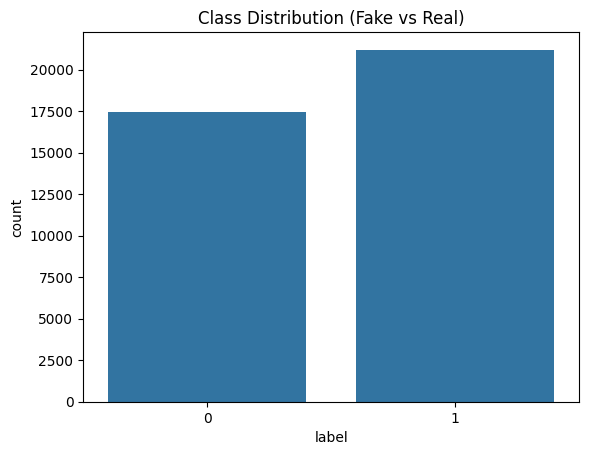

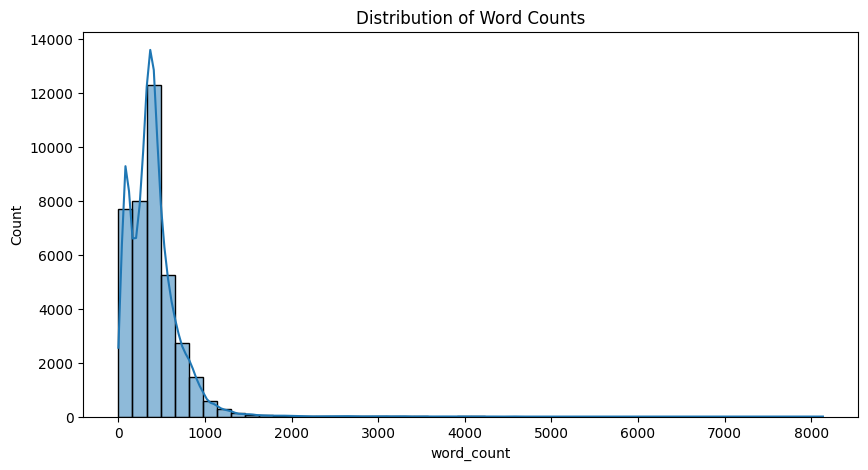

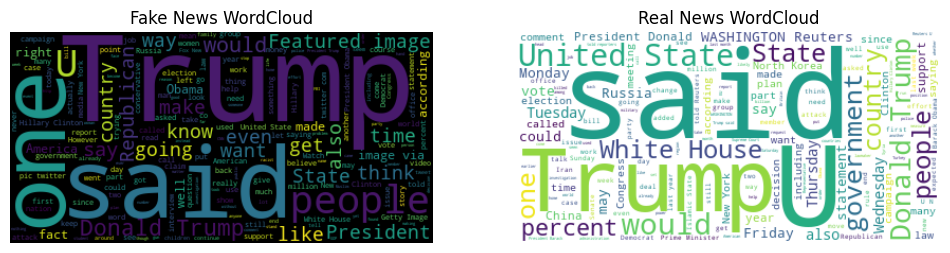

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

# Load data
df = pd.read_pickle("../../data/processed/welfake_cleaned")

# 1. Class distribution
sns.countplot(x=df['label'])
plt.title("Class Distribution (Fake vs Real)")
plt.show()

# 2. Text length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Distribution of Word Counts")
plt.show()

# 3. WordCloud for Fake news
real_text = " ".join(df[df['label']==1]['text'])
fake_text = " ".join(df[df['label']==0]['text'])

wc_fake = WordCloud(stopwords=set(stopwords.words('english')), background_color="black").generate(fake_text)
wc_real = WordCloud(stopwords=set(stopwords.words('english')), background_color="white").generate(real_text)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_fake, interpolation="bilinear")
plt.title("Fake News WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real, interpolation="bilinear")
plt.title("Real News WordCloud")
plt.axis("off")

plt.show()


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, ngram_range=(2,2), n=None):
    """
    Extract top n n-grams from corpus
    """
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:n]

# Fake news bigrams
fake_texts = df[df['label']==0]['text']
fake_bigrams = get_top_ngrams(fake_texts, ngram_range=(2,2), n=20)
fake_trigrams = get_top_ngrams(fake_texts, ngram_range=(3,3), n=20)

# Real news bigrams
real_texts = df[df['label']==1]['text']
real_bigrams = get_top_ngrams(real_texts, ngram_range=(2,2), n=20)
real_trigrams = get_top_ngrams(real_texts, ngram_range=(3,3), n=20)

# Convert to DataFrame for better visualization
print("Top Fake Bigrams:\n", pd.DataFrame(fake_bigrams, columns=['bigram','count']))
print("\nTop Real Bigrams:\n", pd.DataFrame(real_bigrams, columns=['bigram','count']))
print("\nTop Fake Trigrams:\n", pd.DataFrame(fake_trigrams, columns=['trigram','count']))
print("\nTop Real Trigrams:\n", pd.DataFrame(real_trigrams, columns=['trigram','count']))


Top Fake Bigrams:
                    bigram  count
0            donald trump  14025
1          featured image   7691
2         hillary clinton   5431
3             white house   5199
4             twitter com   5124
5           united states   4955
6             pic twitter   4909
7            getty images   4022
8         president obama   3450
9                new york   3154
10               fox news   2675
11        president trump   2610
12               year old   2010
13         trump campaign   1615
14           barack obama   1569
15  trump realdonaldtrump   1532
16          supreme court   1455
17       republican party   1362
18               ted cruz   1344
19         screen capture   1334

Top Real Bigrams:
                   bigram  count
0          united states  12016
1           donald trump  10085
2            white house   8326
3     washington reuters   6638
4       president donald   5865
5            north korea   5504
6               new york   4714
7         pr

C:\Users\kknah\AppData\Local\Temp\ipykernel_9748\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


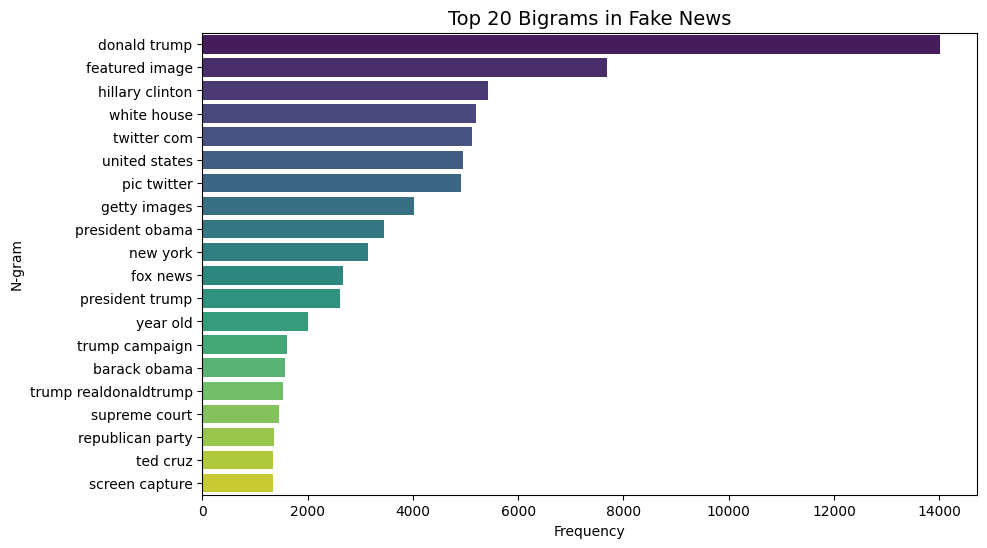

C:\Users\kknah\AppData\Local\Temp\ipykernel_9748\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


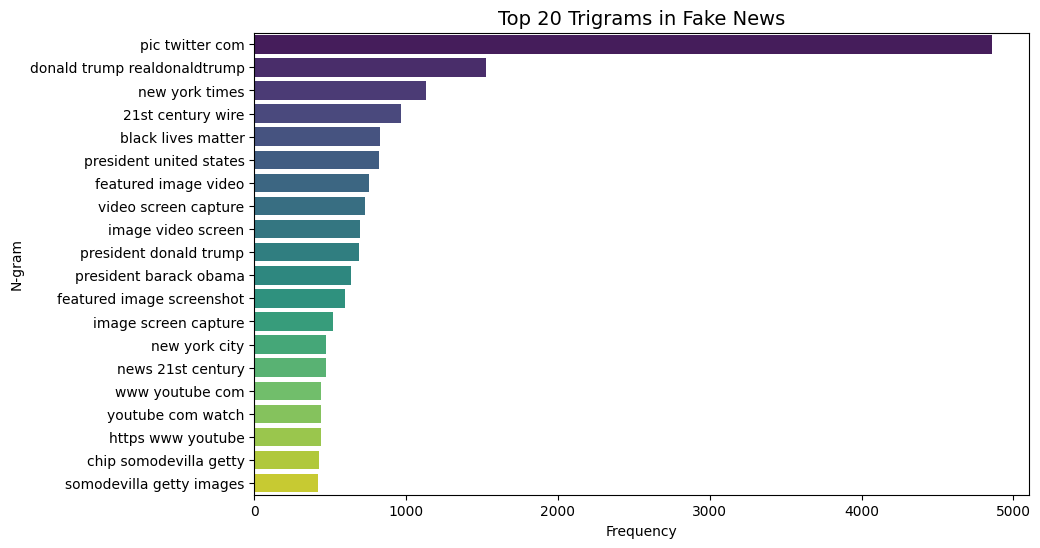

C:\Users\kknah\AppData\Local\Temp\ipykernel_9748\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


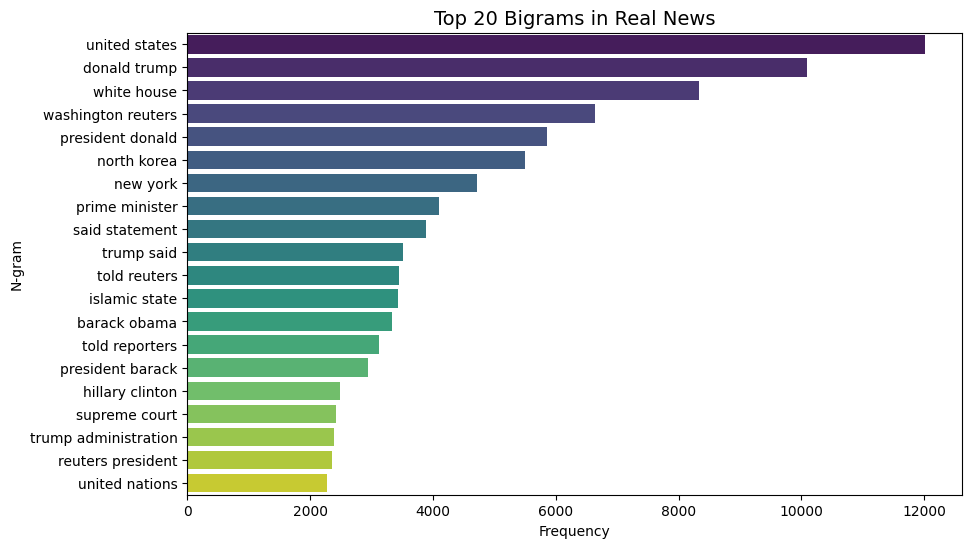

C:\Users\kknah\AppData\Local\Temp\ipykernel_9748\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


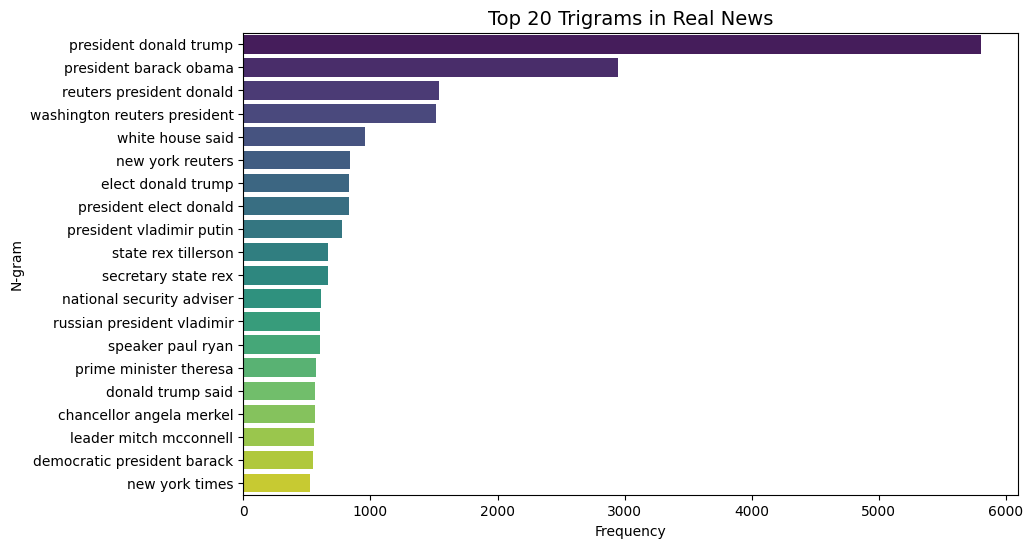

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ngrams(ngrams, title, n=20):
    df_ngram = pd.DataFrame(ngrams, columns=["ngram", "count"])
    plt.figure(figsize=(10,6))
    sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")
    plt.title(title, fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

# Fake news bigrams & trigrams
plot_ngrams(fake_bigrams, "Top 20 Bigrams in Fake News")
plot_ngrams(fake_trigrams, "Top 20 Trigrams in Fake News")

# Real news bigrams & trigrams
plot_ngrams(real_bigrams, "Top 20 Bigrams in Real News")
plot_ngrams(real_trigrams, "Top 20 Trigrams in Real News")
